In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

MATRIX_PATH = Path(
    "D:/Github/generate_amr/data/liputan6/adjacency_matrices/dev/1.npy"
)

matrix = np.load(MATRIX_PATH, allow_pickle=False)

print("Shape:", matrix.shape)
print("Dtype:", matrix.dtype)
print("Minimum:", matrix.min())
print("Maximum:", matrix.max())

labels = [f"sentence_{i}" for i in range(matrix.shape[0])]
matrix_df = pd.DataFrame(matrix, index=labels, columns=labels)

display(matrix_df.round(4))

Shape: (10, 10)
Dtype: float32
Minimum: 0.0
Maximum: 0.33734939


,sentence_0,sentence_1,sentence_2,sentence_3,sentence_4,sentence_5,sentence_6,sentence_7,sentence_8,sentence_9
sentence_0,0.0000,0.1905,0.1500,0.2222,0.2750,0.2632,0.2245,0.0984,0.3265,0.2759
sentence_1,0.1905,0.0000,0.1951,0.1429,0.2927,0.1622,0.1356,0.1818,0.2373,0.1667
sentence_2,0.1500,0.1951,0.0000,0.2373,0.1379,0.2593,0.2105,0.1026,0.2368,0.2769
sentence_3,0.2222,0.1429,0.2373,0.0000,0.2712,0.2909,0.2078,0.1500,0.2338,0.3030
sentence_4,0.2750,0.2927,0.1379,0.2712,0.0000,0.2222,0.1579,0.1538,0.2632,0.2462
sentence_5,0.2632,0.1622,0.2593,0.2909,0.2222,0.0000,0.3056,0.1714,0.3056,0.2951
sentence_6,0.2245,0.1356,0.2105,0.2078,0.1579,0.3056,0.0000,0.1754,0.2128,0.2410
sentence_7,0.0984,0.1818,0.1026,0.1500,0.1538,0.1714,0.1754,0.0000,0.1053,0.1304
sentence_8,0.3265,0.2373,0.2368,0.2338,0.2632,0.3056,0.2128,0.1053,0.0000,0.3373
sentence_9,0.2759,0.1667,0.2769,0.3030,0.2462,0.2951,0.2410,0.1304,0.3373,0.0000


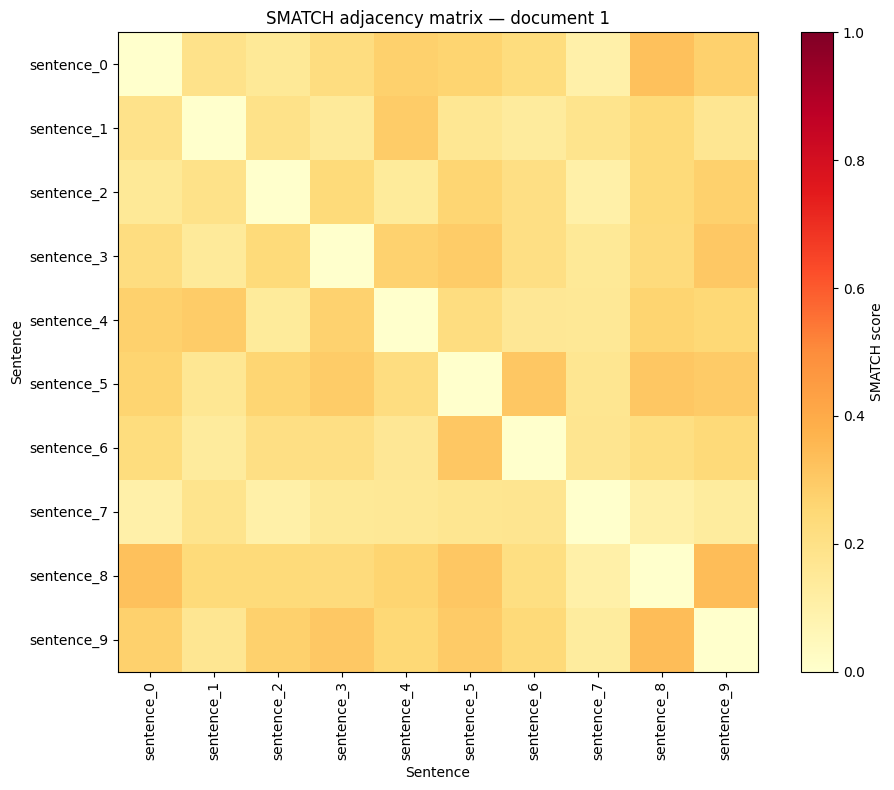

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
image = plt.imshow(matrix, cmap="YlOrRd", vmin=0, vmax=1)

plt.colorbar(image, label="SMATCH score")
plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)
plt.title(f"SMATCH adjacency matrix — document {MATRIX_PATH.stem}")
plt.xlabel("Sentence")
plt.ylabel("Sentence")
plt.tight_layout()
plt.show()

In [5]:
if matrix.shape[0] < 2:
    print("Document contains fewer than two sentences.")
else:
    row_indices, column_indices = np.triu_indices(matrix.shape[0], k=1)
    scores = matrix[row_indices, column_indices]

    max_position = np.argmax(scores)
    sentence_i = int(row_indices[max_position])
    sentence_j = int(column_indices[max_position])
    max_score = float(scores[max_position])

    print("Highest-SMATCH pair:", (sentence_i, sentence_j))
    print("SMATCH score:", max_score)

Highest-SMATCH pair: (8, 9)
SMATCH score: 0.33734938502311707
